## Finetune eval: generalization trend lines

This notebook loads `results/finetune_eval/**/checkpoint-*/results*.json` outputs and plots **arc_easy accuracy (x-axis)** versus other benchmark accuracies (y-axis) as subplots.

- Each **run** (e.g. `mamba-2.8b-alpaca-lr1e-4`) is drawn as a **line** over checkpoints.
- Metrics use `acc_norm` when available, else `acc`.

If a run has no `results*.json` (e.g. an in-progress eval that only produced `eval.log`), it will be skipped and listed in the summary.

In [1]:
from __future__ import annotations

import os
import json
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_repo_root(start: Path | None = None) -> Path | None:
    """Find the *Interplay-LM-Reasoning* repo root.

    Important: Jupyter's working directory can be unrelated to the notebook path.
    So we avoid blindly using CWD if it matches some other repo.

    We look for markers that should be unique to this repo:
    - `analyze/`
    - `results/`
    - `dllm/`
    - `scripts/finetune/`
    """

    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (
            (d / "analyze").is_dir()
            and (d / "results").is_dir()
            and (d / "dllm").is_dir()
            and (d / "scripts" / "finetune").is_dir()
        ):
            return d
    return None


def _pick_existing_dir(candidates: list[Path]) -> Path | None:
    for c in candidates:
        if c is None:
            continue
        c = Path(c).expanduser().resolve()
        if (
            (c / "analyze").is_dir()
            and (c / "results").is_dir()
            and (c / "dllm").is_dir()
            and (c / "scripts" / "finetune").is_dir()
        ):
            return c
    return None


# --- Always chdir into the correct repo root ---
# Override if needed:
#   export INTERPLAY_LM_REASONING_ROOT=/path/to/Interplay-LM-Reasoning
_repo_env = os.environ.get("INTERPLAY_LM_REASONING_ROOT")

REPO_ROOT = _pick_existing_dir(
    [
        Path(_repo_env) if _repo_env else None,
        # Common paths on this cluster
        Path("/fast/pmayilvahanan/Interplay-LM-Reasoning"),
        Path("/lustre/fast/fast/pmayilvahanan/Interplay-LM-Reasoning"),
    ]
) or _find_repo_root()

if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the Interplay-LM-Reasoning repo root. "
        "Set INTERPLAY_LM_REASONING_ROOT or edit REPO_ROOT candidates in this cell."
    )

os.chdir(REPO_ROOT)


def _resolve_results_root() -> Path:
    p = Path("results/finetune_eval")
    if p.exists() and p.is_dir():
        return p
    raise FileNotFoundError(
        f"Could not find finetune eval results at {p.resolve()}. Make sure evaluations have been run."
    )


RESULTS_ROOT = _resolve_results_root()

# Always plot these tasks (x fixed to arc_easy)
X_TASK = "arc_easy"
Y_TASKS = [
    "hellaswag",
    "mmlu",
    "arc_challenge",
    "piqa",
    "winogrande",
    "openbookqa",
    "commonsense_qa",
]

MODEL_COLORS = {
    "pythia": "#1f77b4",
    "mamba": "#2ca02c",
    "bd3lm": "#ff7f0e",
    "mdlm": "#d62728",
}

MODEL_LINESTYLES = {
    "pythia": "-",
    "mamba": "-",
    "bd3lm": "--",
    "mdlm": "--",
}

# Metric selection:
# - "acc_norm": length-normalized candidate-ranking accuracy when available
# - "acc": unnormalized candidate-ranking accuracy
METRIC = "acc_norm"
FALLBACK_METRIC = True


def _pick_acc(
    task_metrics: dict,
    metric: str = METRIC,
    fallback: bool = FALLBACK_METRIC,
) -> float | None:
    """Pick accuracy metric from a lm-eval task result dict."""
    if not isinstance(task_metrics, dict):
        return None

    key_map = {"acc": "acc,none", "acc_norm": "acc_norm,none"}
    if metric not in key_map:
        raise ValueError(f"metric must be one of {sorted(key_map)}; got {metric!r}")

    primary = key_map[metric]
    if primary in task_metrics:
        return float(task_metrics[primary])

    if not fallback:
        return None

    secondary = key_map["acc_norm" if metric == "acc" else "acc"]
    if secondary in task_metrics:
        return float(task_metrics[secondary])

    return None


def _load_results_dict(results_path: Path) -> dict:
    data = json.loads(results_path.read_text())
    # lm-eval-harness format
    if isinstance(data, dict) and "results" in data and isinstance(data["results"], dict):
        return data["results"]
    return data


def _find_results_file(ckpt_dir: Path) -> Path | None:
    """Find a lm-eval results file under a checkpoint directory."""
    patterns = [
        "results.json",
        "results_*.json",
        "*/results.json",
        "*/results_*.json",
    ]
    matches: list[Path] = []
    for pat in patterns:
        matches.extend([p for p in ckpt_dir.glob(pat) if p.is_file()])

    if not matches:
        return None

    # Prefer results.json if present; else newest results_*.json
    for p in matches:
        if p.name == "results.json":
            return p
    return max(matches, key=lambda p: p.stat().st_mtime)


_CKPT_RE = re.compile(r"^checkpoint-(\d+)$")


def _parse_step(ckpt_name: str) -> int | None:
    m = _CKPT_RE.match(ckpt_name)
    if m:
        return int(m.group(1))
    return None


@dataclass(frozen=True)
class RunId:
    model_type: str
    run_name: str

    @property
    def label(self) -> str:
        return f"{self.model_type}/{self.run_name}"


def load_finetune_eval(
    results_root: Path = RESULTS_ROOT,
    model_types: Iterable[str] | None = None,
    run_name_regex: str | None = None,
    metric: str = METRIC,
    fallback_metric: bool = FALLBACK_METRIC,
) -> tuple[pd.DataFrame, list[str]]:
    """Load per-checkpoint accuracies from results_root.

    Returns (df, skipped_runs).
    """
    model_types_set = set(model_types) if model_types is not None else None
    run_pat = re.compile(run_name_regex) if run_name_regex else None

    rows: list[dict] = []
    skipped: list[str] = []

    for model_dir in sorted(results_root.iterdir()):
        if not model_dir.is_dir():
            continue
        model_type = model_dir.name
        if model_types_set is not None and model_type not in model_types_set:
            continue

        for run_dir in sorted(model_dir.iterdir()):
            if not run_dir.is_dir():
                continue
            if run_pat is not None and run_pat.search(run_dir.name) is None:
                continue

            run_id = RunId(model_type=model_type, run_name=run_dir.name)
            found_any = False

            for ckpt_dir in sorted(run_dir.iterdir()):
                if not ckpt_dir.is_dir():
                    continue

                results_file = _find_results_file(ckpt_dir)
                if results_file is None:
                    continue

                found_any = True
                results = _load_results_dict(results_file)

                row = {
                    "model_type": model_type,
                    "run_name": run_dir.name,
                    "run_id": run_id.label,
                    "checkpoint": ckpt_dir.name,
                    "step": _parse_step(ckpt_dir.name),
                    "results_path": str(results_file),
                }

                for task in [X_TASK, *Y_TASKS]:
                    row[f"{task}_acc"] = _pick_acc(
                        results.get(task, {}),
                        metric=metric,
                        fallback=fallback_metric,
                    )

                rows.append(row)

            if not found_any:
                skipped.append(run_id.label)

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df, skipped

    # Fill in missing step (e.g. checkpoint-final) as max(step)+1 within each run.
    def _fill_steps(g: pd.DataFrame) -> pd.DataFrame:
        steps = g["step"].dropna()
        max_step = int(steps.max()) if len(steps) else 0
        g.loc[g["step"].isna(), "step"] = max_step + 1
        g["step"] = g["step"].astype(int)
        return g

    df = df.groupby("run_id", group_keys=False).apply(_fill_steps)
    return df, skipped


plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

In [2]:
df, skipped_runs = load_finetune_eval(metric=METRIC, fallback_metric=FALLBACK_METRIC)

print("REPO_ROOT:", REPO_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)
print(f"metric: {METRIC} (fallback={FALLBACK_METRIC})")
print("loaded rows:", len(df))
print("unique runs:", df["run_id"].nunique() if len(df) else 0)

if skipped_runs:
    print("\nRuns with no results*.json (skipped):")
    for r in skipped_runs:
        print(" -", r)

if len(df):
    display(
        df.groupby(["model_type", "run_name"])  # noqa: F821
        .agg(n_checkpoints=("checkpoint", "nunique"))
        .sort_values(["model_type", "n_checkpoints"], ascending=[True, False])
    )
    
    # Quick sanity: show which tasks have missing acc
    cols = [f"{t}_acc" for t in [X_TASK, *Y_TASKS]]
    missing = df[cols].isna().mean().sort_values(ascending=False)
    display(missing.to_frame("fraction_missing"))  # noqa: F821

    # Variance diagnostics (range in percentage points) for arc_easy
    arc = (
        df.groupby("run_id")[f"{X_TASK}_acc"]
        .agg(["count", "min", "max", "std"])
        .sort_values("count", ascending=False)
    )
    arc["range_pp"] = (arc["max"] - arc["min"]) * 100
    display(arc.sort_values("range_pp"))  # noqa: F821

REPO_ROOT: /lustre/fast/fast/pmayilvahanan/Interplay-LM-Reasoning
RESULTS_ROOT: results/finetune_eval
metric: acc_norm (fallback=True)
loaded rows: 68
unique runs: 9


n_checkpoints
model_type run_name                                    
bd3lm      pythia-2.8b-bd3lm-bs1-alpaca               7
           pythia-2.8b-bd3lm-bs32-alpaca              6
mamba      mamba-2.8b-alpaca                          8
           mamba-2.8b-alpaca-lr1.5e-4                 8
           mamba-2.8b-alpaca-lr1e-4                   8
           mamba-2.8b-alpaca-lr2.5e-4                 8
           mamba-2.8b-alpaca-lr5e-5                   8
mdlm       pythia-2.8b-mdlm-alpaca                    7
pythia     pythia-2.8b-alpaca                         8

,fraction_missing
arc_easy_acc,0.0
hellaswag_acc,0.0
mmlu_acc,0.0
arc_challenge_acc,0.0
piqa_acc,0.0
winogrande_acc,0.0
openbookqa_acc,0.0
commonsense_qa_acc,0.0


,count,min,max,std,range_pp
run_id,,,,,
bd3lm/pythia-2.8b-bd3lm-bs1-alpaca,7,0.283670,0.290825,0.002390,0.715488
mamba/mamba-2.8b-alpaca,8,0.648569,0.665825,0.006553,1.725589
mamba/mamba-2.8b-alpaca-lr1e-4,8,0.591330,0.612374,0.006921,2.104377
mamba/mamba-2.8b-alpaca-lr2.5e-4,8,0.535774,0.557239,0.008420,2.146465
pythia/pythia-2.8b-alpaca,8,0.551347,0.573232,0.006632,2.188552
mamba/mamba-2.8b-alpaca-lr5e-5,8,0.611953,0.637205,0.009000,2.525253
mamba/mamba-2.8b-alpaca-lr1.5e-4,8,0.564815,0.591330,0.008420,2.651515
mdlm/pythia-2.8b-mdlm-alpaca,7,0.472643,0.513047,0.015868,4.040404
bd3lm/pythia-2.8b-bd3lm-bs32-alpaca,6,0.432660,0.485690,0.022021,5.303030


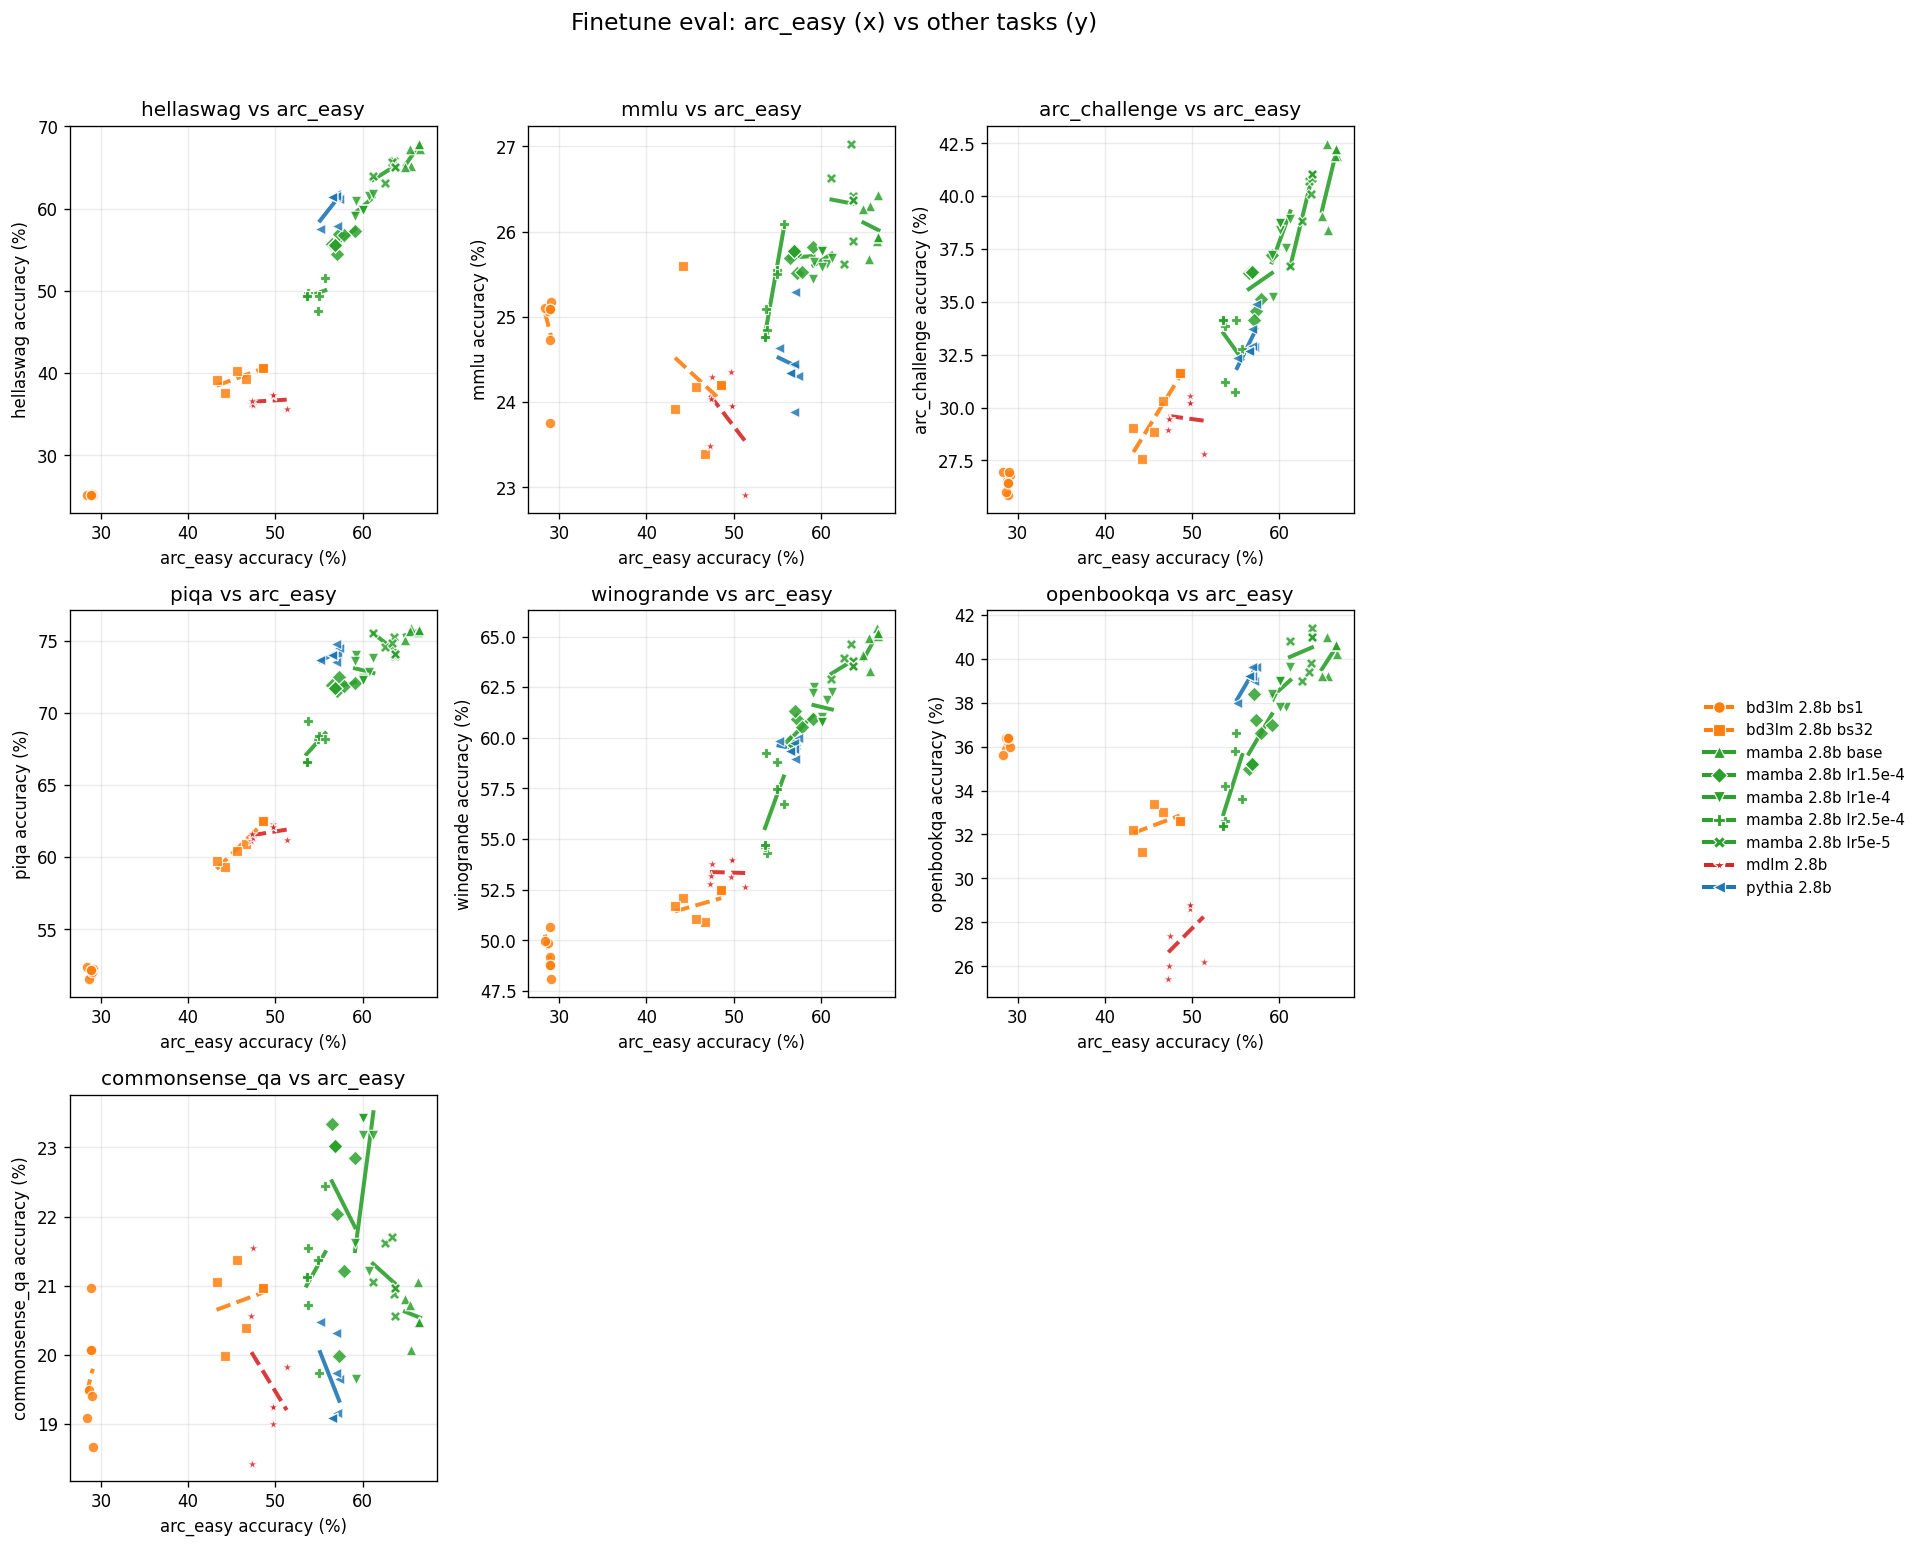

In [3]:
def plot_arc_easy_vs_tasks(
    df: pd.DataFrame,
    x_task: str = X_TASK,
    y_tasks: list[str] = Y_TASKS,
    run_ids: list[str] | None = None,
    legend_max_cols: int = 1,
    min_points_fit: int = 3,
    use_pretty_labels: bool = True,
):
    if len(df) == 0:
        raise ValueError("Empty dataframe: no eval results found.")

    if run_ids is None:
        run_ids = sorted(df["run_id"].unique())

    # Style mapping (marker per run, color per model_type)
    from matplotlib.lines import Line2D

    marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h"]
    marker_map = {
        rid: marker_cycle[i % len(marker_cycle)] for i, rid in enumerate(run_ids)
    }

    def _pretty_label(rid: str) -> str:
        if not use_pretty_labels:
            return rid
        if "/" not in rid:
            return rid

        model_type, run_name = rid.split("/", 1)
        m_size = re.search(r"([0-9]+(?:[.][0-9]+)?b)", run_name)
        size = m_size.group(1) if m_size else None

        if model_type == "mamba":
            m_lr = re.search(r"lr([0-9.e-]+)", run_name)
            lr = f"lr{m_lr.group(1)}" if m_lr else "base"
            parts = ["mamba", size, lr]
            return " ".join([p for p in parts if p])

        if model_type == "pythia":
            parts = ["pythia", size]
            return " ".join([p for p in parts if p]) or rid

        if model_type == "bd3lm":
            m_bs = re.search(r"bs([0-9]+)", run_name)
            bs = f"bs{m_bs.group(1)}" if m_bs else None
            parts = ["bd3lm", size, bs]
            return " ".join([p for p in parts if p]) or rid

        if model_type == "mdlm":
            parts = ["mdlm", size]
            return " ".join([p for p in parts if p]) or rid

        return rid

    legend_labels = [_pretty_label(rid) for rid in run_ids]
    if len(set(legend_labels)) != len(legend_labels):
        legend_labels = run_ids

    run_to_model = df.groupby("run_id")["model_type"].first().to_dict()
    legend_handles = []
    for rid in run_ids:
        model_type = run_to_model.get(rid, "")
        color = MODEL_COLORS.get(model_type, "gray")
        ls = MODEL_LINESTYLES.get(model_type, "-")
        marker = marker_map[rid]
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=color,
                linestyle=ls,
                linewidth=2.4,
                marker=marker,
                markersize=7,
                markerfacecolor=color,
                markeredgecolor="white",
                markeredgewidth=0.7,
            )
        )

    n = len(y_tasks)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax_idx, task_y in enumerate(y_tasks):
        ax = axes[ax_idx]
        col_x = f"{x_task}_acc"
        col_y = f"{task_y}_acc"

        for run_id in run_ids:
            sub = df[df["run_id"] == run_id].copy()
            sub = sub[sub[col_x].notna() & sub[col_y].notna()].sort_values("step")
            if len(sub) < 2:
                continue

            model_type = sub["model_type"].iloc[0]
            color = MODEL_COLORS.get(model_type, "gray")
            ls = MODEL_LINESTYLES.get(model_type, "-")

            x = sub[col_x].to_numpy() * 100
            y = sub[col_y].to_numpy() * 100

            marker = marker_map[run_id]

            # Show checkpoint points
            ax.scatter(
                x,
                y,
                s=40,
                marker=marker,
                color=color,
                edgecolor="white",
                linewidth=0.7,
                alpha=0.85,
                zorder=3,
            )

            # Fit a clean trend line (like the reference figure): y ~ x
            if len(x) >= 2:
                x_rng = float(np.ptp(x))
                y_rng = float(np.ptp(y))

                if x_rng <= 1e-6 and y_rng <= 1e-6:
                    # Completely flat: nothing to fit (points already shown)
                    pass
                elif x_rng <= 1e-6:
                    # Vertical trend (x constant)
                    ax.plot(
                        [float(x.mean()), float(x.mean())],
                        [float(y.min()), float(y.max())],
                        color=color,
                        linestyle=ls,
                        linewidth=2.4,
                        alpha=0.9,
                        zorder=2,
                    )
                elif y_rng <= 1e-6:
                    # Horizontal trend (y constant)
                    ax.plot(
                        [float(x.min()), float(x.max())],
                        [float(y.mean()), float(y.mean())],
                        color=color,
                        linestyle=ls,
                        linewidth=2.4,
                        alpha=0.9,
                        zorder=2,
                    )
                elif len(x) >= min_points_fit:
                    slope, intercept = np.polyfit(x, y, 1)
                    x_fit = np.linspace(float(x.min()), float(x.max()), 100)
                    y_fit = slope * x_fit + intercept
                    ax.plot(
                        x_fit,
                        y_fit,
                        color=color,
                        linestyle=ls,
                        linewidth=2.4,
                        alpha=0.9,
                        zorder=2,
                    )
                else:
                    # With only 2 points, the fit is just the connecting segment.
                    order = np.argsort(x)
                    ax.plot(
                        x[order],
                        y[order],
                        color=color,
                        linestyle=ls,
                        linewidth=2.4,
                        alpha=0.9,
                        zorder=2,
                    )

        ax.set_title(f"{task_y} vs {x_task}")
        ax.set_xlabel(f"{x_task} accuracy (%)")
        ax.set_ylabel(f"{task_y} accuracy (%)")

    # Hide unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    # One shared legend (one entry per run)
    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            frameon=False,
            ncol=legend_max_cols,
            fontsize=9,
        )

    fig.suptitle("Finetune eval: arc_easy (x) vs other tasks (y)", y=1.02, fontsize=14)
    # Leave room on the right for the legend
    fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0))
    return fig


# Choose which runs to plot (None = all runs with results)
RUN_IDS = None  # e.g. ["mamba/mamba-2.8b-alpaca", "bd3lm/pythia-2.8b-bd3lm-bs32-alpaca"]

fig = plot_arc_easy_vs_tasks(df, run_ids=RUN_IDS)
plt.show()